# Pothole Detection — Roboflow Dataset v14

This notebook replaces the previous RDD2022 dataset with the Roboflow **Pothole Segmentation v14** dataset.

Workflow:
1. Install dependencies
2. Mount Google Drive
3. Download Roboflow v14 in YOLOv8 format
4. Inspect the dataset and `data.yaml`
5. Determine whether the labels are detection or segmentation
6. Visualize sample annotations
7. Train a **new** model
8. Validate it
9. Run predictions on custom images

**Important:** This is a new dataset, so do **not** use `resume=True` with the old RDD2022 checkpoints.


## 1. Install dependencies

In [1]:
!pip install -U ultralytics roboflow pyyaml matplotlib opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfull

## 2. Import libraries and check GPU

In [1]:
import os
import glob
import yaml
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import cv2

from ultralytics import YOLO

print("Ultralytics imported successfully!")

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics imported successfully!
CUDA available: True
GPU: Tesla T4


## 3. Mount Google Drive

Drive is used for persistent training outputs/checkpoints.

The downloaded dataset itself is kept in `/content` during training to reduce slow mounted-Drive image access.


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 4. Download Roboflow Pothole Segmentation v14

**Security:** The API key should not be committed to a notebook or shared publicly. If an API key has already been exposed, revoke/regenerate it in Roboflow.

Replace `YOUR_NEW_ROBOFLOW_API_KEY` below.


In [3]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "XgnrdkrD2jrcSAiJoiHY"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("gp-grakz").project("pothole-segmentation-g6hbh")
version = project.version(14)

dataset = version.download("yolov8")

DATASET_DIR = dataset.location

print("✅ Dataset downloaded!")
print("Dataset location:", DATASET_DIR)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-Segmentation-14 in yolov8:: 100%|██████████| 6700/6700 [00:01<00:00, 6318.50it/s]


✅ Dataset downloaded!
Dataset location: /content/Pothole-Segmentation-14


## 5. Inspect the downloaded dataset

In [4]:
print("Top-level contents:")
for item in sorted(os.listdir(DATASET_DIR)):
    print(" -", item)

print("\nDirectory structure:")
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")


Top-level contents:
 - README.dataset.txt
 - README.roboflow.txt
 - data.yaml
 - test
 - train
 - valid

Directory structure:
Pothole-Segmentation-14/
  valid/
    images/
    labels/
  test/
    images/
    labels/
  train/
    images/
    labels/


## 6. Inspect `data.yaml`

In [5]:
yaml_path = os.path.join(DATASET_DIR, "data.yaml")

if not os.path.exists(yaml_path):
    raise FileNotFoundError(f"data.yaml not found at: {yaml_path}")

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
print(yaml.safe_dump(data_config, sort_keys=False))

print("Dataset classes:", data_config.get("names"))
print("Number of classes:", data_config.get("nc"))


data.yaml contents:
names:
- Manhole
- Pothole
- Unmarked Bump
nc: 3
roboflow:
  license: CC BY 4.0
  project: pothole-segmentation-g6hbh
  url: https://universe.roboflow.com/gp-grakz/pothole-segmentation-g6hbh/dataset/14
  version: 14
  workspace: gp-grakz
test: ../test/images
train: ../train/images
val: ../valid/images

Dataset classes: ['Manhole', 'Pothole', 'Unmarked Bump']
Number of classes: 3


## 7. Resolve the train/validation/test directories

Roboflow may use `valid` or `val`. This cell resolves the actual directories from the generated YAML.


In [6]:
from pathlib import Path
import yaml

DATASET_DIR = Path(dataset.location)

print("Dataset location:", DATASET_DIR)
print("\nDataset contents:")
for p in DATASET_DIR.iterdir():
    print(p)

yaml_files = list(DATASET_DIR.glob("*.yaml"))
print("\nYAML files:", yaml_files)

if not yaml_files:
    raise FileNotFoundError("No data.yaml found in the Roboflow dataset.")

DATA_YAML = yaml_files[0]

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\nRoboflow data.yaml:")
print(data)

Dataset location: /content/Pothole-Segmentation-14

Dataset contents:
/content/Pothole-Segmentation-14/README.roboflow.txt
/content/Pothole-Segmentation-14/data.yaml
/content/Pothole-Segmentation-14/README.dataset.txt
/content/Pothole-Segmentation-14/valid
/content/Pothole-Segmentation-14/test
/content/Pothole-Segmentation-14/train

YAML files: [PosixPath('/content/Pothole-Segmentation-14/data.yaml')]

Roboflow data.yaml:
{'names': ['Manhole', 'Pothole', 'Unmarked Bump'], 'nc': 3, 'roboflow': {'license': 'CC BY 4.0', 'project': 'pothole-segmentation-g6hbh', 'url': 'https://universe.roboflow.com/gp-grakz/pothole-segmentation-g6hbh/dataset/14', 'version': 14, 'workspace': 'gp-grakz'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


## 8. Count images and labels

In [7]:
from pathlib import Path

DATASET_DIR = Path("/content/Pothole-Segmentation-14")

TRAIN_DIR = DATASET_DIR / "train" / "images"
VAL_DIR = DATASET_DIR / "valid" / "images"
TEST_DIR = DATASET_DIR / "test" / "images"

print("DATASET_DIR:", DATASET_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

print("\nExistence:")
print("TRAIN:", TRAIN_DIR.exists())
print("VAL:", VAL_DIR.exists())
print("TEST:", TEST_DIR.exists())

DATASET_DIR: /content/Pothole-Segmentation-14
TRAIN_DIR: /content/Pothole-Segmentation-14/train/images
VAL_DIR: /content/Pothole-Segmentation-14/valid/images
TEST_DIR: /content/Pothole-Segmentation-14/test/images

Existence:
TRAIN: True
VAL: True
TEST: True


## 9. Inspect label format

This is important because the Roboflow project is named **Pothole Segmentation**.

- Detection YOLO labels normally contain: `class x_center y_center width height`
- Segmentation YOLO labels normally contain: `class x1 y1 x2 y2 ...`

The cell below samples labels and reports their token counts.


In [8]:
def inspect_labels(split_dir, max_files=10):
    label_dir = os.path.join(split_dir, "labels")
    files = sorted(glob.glob(os.path.join(label_dir, "*.txt")))[:max_files]

    print("Label directory:", label_dir)
    print("Files inspected:", len(files))

    for path in files:
        with open(path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        print("\n", os.path.basename(path))
        for line in lines[:3]:
            parts = line.split()
            print(" token count:", len(parts))
            print(" ", line[:250])

inspect_labels(TRAIN_DIR)


Label directory: /content/Pothole-Segmentation-14/train/images/labels
Files inspected: 0


## 10. Automatically determine detection vs segmentation

For one-class pothole data:
- 5 values per annotation line → detection
- More than 5 values → segmentation polygon


In [9]:
from pathlib import Path

LABEL_DIR = DATASET_DIR / "train" / "labels"

print("LABEL_DIR:", LABEL_DIR)
print("Exists:", LABEL_DIR.exists())

label_files = list(LABEL_DIR.glob("*.txt"))

print("Number of label files:", len(label_files))

if not label_files:
    raise RuntimeError(f"No label files found in {LABEL_DIR}")

sample_label = label_files[0]

print("\nSample label file:")
print(sample_label)

print("\nContents:")
print(sample_label.read_text())

LABEL_DIR: /content/Pothole-Segmentation-14/train/labels
Exists: True
Number of label files: 2690

Sample label file:
/content/Pothole-Segmentation-14/train/labels/youtube-14_jpg.rf.df08235e62ccefa8b2654d2311cad8d6.txt

Contents:
1 0.5500399515625001 0.7267157828124999 0.4979749078125 0.7143773671875 0.4493808671875 0.704095403125 0.4146708390625 0.6958698875 0.45747990937500005 0.7637307437499999 0.5488829156249999 0.7966328078125 0.62987301875 0.7781253265625 0.5882209828125 0.739054103125 0.5500399515625001 0.7267157828124999
1 0.06062854375 0.7534486859375 0.15087461875 0.7226028828125 0.1439326125 0.69175708125 0.0849255640625 0.6979262421875 0.0775180671875 0.7092110421875 0.06062854375 0.7534486859375
1 0.1123046875 0.62109375 0.103515625 0.6318359375 0.1123046875 0.64453125 0.1171875 0.6435546875 0.1328125 0.6279296875 0.1123046875 0.62109375
1 0.6953125 0.4658203125 0.6806640625 0.458984375 0.662109375 0.4619140625 0.6689453125 0.470703125 0.68359375 0.4716796875 0.6943359375 

In [10]:
lines = sample_label.read_text().strip().splitlines()

print("Number of annotation lines:", len(lines))

for i, line in enumerate(lines[:5]):
    values = line.split()
    print(f"Line {i+1}:")
    print("  Values:", values)
    print("  Number of values:", len(values))

Number of annotation lines: 11
Line 1:
  Values: ['1', '0.5500399515625001', '0.7267157828124999', '0.4979749078125', '0.7143773671875', '0.4493808671875', '0.704095403125', '0.4146708390625', '0.6958698875', '0.45747990937500005', '0.7637307437499999', '0.5488829156249999', '0.7966328078125', '0.62987301875', '0.7781253265625', '0.5882209828125', '0.739054103125', '0.5500399515625001', '0.7267157828124999']
  Number of values: 19
Line 2:
  Values: ['1', '0.06062854375', '0.7534486859375', '0.15087461875', '0.7226028828125', '0.1439326125', '0.69175708125', '0.0849255640625', '0.6979262421875', '0.0775180671875', '0.7092110421875', '0.06062854375', '0.7534486859375']
  Number of values: 13
Line 3:
  Values: ['1', '0.1123046875', '0.62109375', '0.103515625', '0.6318359375', '0.1123046875', '0.64453125', '0.1171875', '0.6435546875', '0.1328125', '0.6279296875', '0.1123046875', '0.62109375']
  Number of values: 13
Line 4:
  Values: ['1', '0.6953125', '0.4658203125', '0.6806640625', '0.458

## 11. Visualize sample training images and labels

This cell supports both YOLO detection boxes and YOLO segmentation polygons.


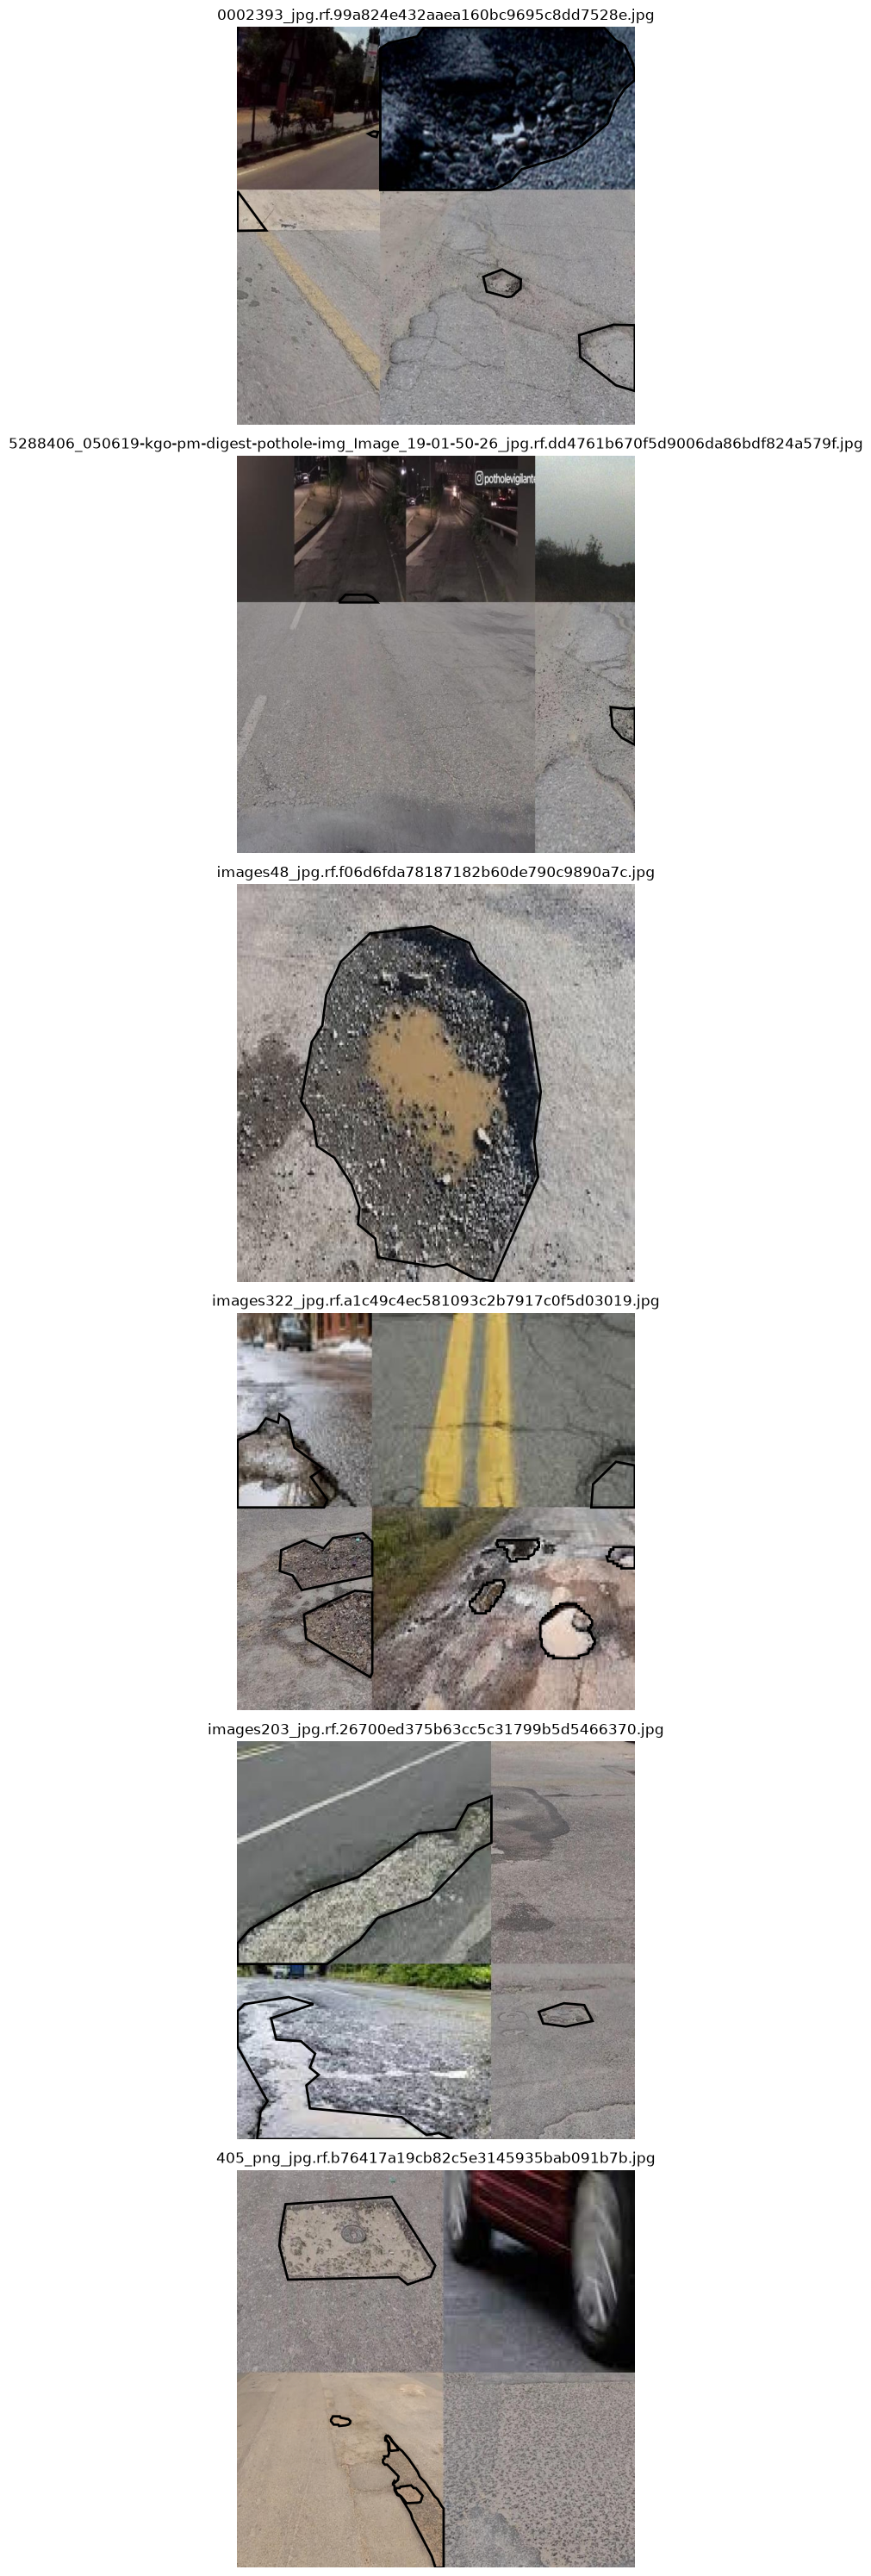

In [11]:
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt

def get_image_files(image_dir):
    image_dir = Path(image_dir)
    return sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in
        [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])

def show_samples(image_dir, n=6):
    image_dir = Path(image_dir)
    images = get_image_files(image_dir)

    if not images:
        print(f"No images found in: {image_dir}")
        return

    selected = random.sample(images, min(n, len(images)))

    label_dir = image_dir.parent / "labels"

    fig, axes = plt.subplots(
        len(selected), 1,
        figsize=(12, 5 * len(selected))
    )

    if len(selected) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, selected):

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        label_path = label_dir / f"{image_path.stem}.txt"

        ax.imshow(image)
        ax.set_title(image_path.name)
        ax.axis("off")

        if label_path.exists():

            with open(label_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]

            for line in lines:

                parts = list(map(float, line.split()))

                cls = int(parts[0])
                coords = parts[1:]

                # YOLO segmentation polygon
                if len(coords) >= 6 and len(coords) % 2 == 0:

                    pts = []

                    for i in range(0, len(coords), 2):
                        x = coords[i] * w
                        y = coords[i + 1] * h
                        pts.append((x, y))

                    if len(pts) >= 3:
                        polygon = plt.Polygon(
                            pts,
                            fill=False,
                            linewidth=2
                        )
                        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n=6)

## 12. Optional: copy the dataset to a persistent Drive location

This is optional. Training should use the `/content` dataset for better I/O.

If you want a persistent copy, uncomment the next cell. It can take time because image datasets are large.


In [ ]:
# PERSISTENT_DATASET_DIR = "/content/drive/MyDrive/PTM/roboflow_pothole_v14"
# if not os.path.exists(PERSISTENT_DATASET_DIR):
#     shutil.copytree(DATASET_DIR, PERSISTENT_DATASET_DIR)
# print("Persistent copy:", PERSISTENT_DATASET_DIR)


## 13. Create a local training YAML

The Roboflow YAML may contain paths tied to its download directory. This creates a clean local YAML using the actual directories.

The class names are taken from Roboflow's `data.yaml`.


In [12]:
from pathlib import Path
import yaml

DATASET_DIR = Path("/content/Pothole-Segmentation-14")

local_config = {
    "path": str(DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {
        0: "Manhole",
        1: "Pothole",
        2: "Unmarked Bump"
    }
}

local_yaml_path = "/content/roboflow_pothole.yaml"

with open(local_yaml_path, "w") as f:
    yaml.safe_dump(local_config, f, sort_keys=False)

print(open(local_yaml_path).read())

path: /content/Pothole-Segmentation-14
train: train/images
val: valid/images
test: test/images
names:
  0: Manhole
  1: Pothole
  2: Unmarked Bump



## 14. Select the correct YOLO model

This automatically selects detection or segmentation based on the labels inspected above.

A fresh pretrained model is used because this is a new dataset.


In [ ]:
MODEL_WEIGHTS = "yolo26n-seg.pt"

print("Detected label format: YOLO segmentation")
print("Model:", MODEL_WEIGHTS)

Detected label format: YOLO segmentation
Model: yolo26n-seg.pt


## 15. Train a NEW model

This is intentionally a new run. Do **not** set `resume=True`.

The output is saved to Google Drive so that the checkpoint survives a Colab runtime disconnect.

If GPU memory is insufficient, reduce `batch` from 16 to 8.


In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=local_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/drive/MyDrive/PTM/pothole_training",
    name="roboflow_pothole_v14_100",
    exist_ok=True
)

print("✅ Training completed.")


Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/roboflow_pothole.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roboflow_pothole_v14_100, nbs=64, nms=Non

In [13]:
from ultralytics import YOLO

checkpoint = "/content/drive/MyDrive/PTM/pothole_training/roboflow_pothole_v14_100/weights/last.pt"

model = YOLO(checkpoint)

results = model.train(
    resume=True
)

print("✅ Training resumed/completed.")

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/roboflow_pothole.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/PTM/pothole_training/roboflow_pothole_v14_100/weights/last.pt, momentum=0.937, mosai

## 16. Validate the trained model

In [14]:
best_model_path = "/content/drive/MyDrive/PTM/pothole_training/roboflow_pothole_v14_100/weights/best.pt"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"best.pt not found: {best_model_path}")

trained_model = YOLO(best_model_path)

metrics = trained_model.val(
    data=local_yaml_path,
    imgsz=640,
    batch=16,
    device=0
)

print(metrics)


Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,469 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2490.5±1003.5 MB/s, size: 71.7 KB)
val: Scanning /content/Pothole-Segmentation-14/valid/labels.cache... 300 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 74.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.3it/s 8.4s
                   all        300        566      0.802      0.467       0.51      0.371      0.802      0.467       0.51      0.362
               Manhole          5          5      0.712      0.509      0.635      0.472      0.712      0.509      0.635      0.445
               Pothole        292        560      0.693      0.891      0.874      0.633      0.693      0.891      0.873      0.632
         Unmarked Bump    

## 17. Show the main validation metrics

In [15]:
try:
    print("Precision:", metrics.results_dict.get("metrics/precision(B)"))
    print("Recall:", metrics.results_dict.get("metrics/recall(B)"))
    print("mAP50:", metrics.results_dict.get("metrics/mAP50(B)"))
    print("mAP50-95:", metrics.results_dict.get("metrics/mAP50-95(B)"))
except Exception as e:
    print("Could not extract box metrics directly.")
    print(e)
    print(metrics.results_dict)


Precision: 0.80183509103353
Recall: 0.466804242548774
mAP50: 0.5100950675835624
mAP50-95: 0.37092171461583506


## 18. Predict on one custom image

Upload an image to Colab first, then set `CUSTOM_IMAGE_PATH`.

Start with `conf=0.25`. Lower thresholds such as 0.10 are useful for diagnosis but should not automatically be used as the final application threshold.


In [ ]:
from google.colab import files

uploaded = files.upload()

if uploaded:
    CUSTOM_IMAGE_PATH = "/content/" + next(iter(uploaded))
    print("Selected:", CUSTOM_IMAGE_PATH)


In [ ]:
if "CUSTOM_IMAGE_PATH" in globals():
    prediction_results = trained_model.predict(
        source=CUSTOM_IMAGE_PATH,
        conf=0.25,
        save=True
    )
    print("Prediction completed.")
else:
    print("Upload an image in the previous cell first.")


## 19. Compare confidence thresholds

This is useful for checking whether low-confidence detections are being suppressed.

Do not interpret a lower confidence threshold as a model improvement by itself.


In [ ]:
if "CUSTOM_IMAGE_PATH" in globals():
    for conf in [0.25, 0.10, 0.05]:
        print(f"\n===== Confidence: {conf} =====")
        trained_model.predict(
            source=CUSTOM_IMAGE_PATH,
            conf=conf,
            save=True
        )
else:
    print("Upload an image first.")


## 20. Predict on multiple custom images

Set `CUSTOM_FOLDER` to a folder containing test images.


In [16]:
from ultralytics import YOLO

# model = YOLO(
#     "/content/drive/MyDrive/PTM/pothole_training/yolo_pothole/weights/best.pt"
# )

results = trained_model.predict(
    source="/content/drive/MyDrive/PTM/images",
    conf=0.25,
    save=True
)


image 1/10 /content/drive/MyDrive/PTM/images/p1.jpeg: 448x640 10 Potholes, 14.4ms
image 2/10 /content/drive/MyDrive/PTM/images/p10.jpeg: 416x640 1 Pothole, 69.7ms
image 3/10 /content/drive/MyDrive/PTM/images/p2.jpeg: 448x640 1 Pothole, 12.8ms
image 4/10 /content/drive/MyDrive/PTM/images/p3.jpeg: 512x640 1 Pothole, 68.6ms
image 5/10 /content/drive/MyDrive/PTM/images/p4.jpeg: 384x640 1 Pothole, 67.3ms
image 6/10 /content/drive/MyDrive/PTM/images/p5.jpeg: 416x640 3 Potholes, 15.1ms
image 7/10 /content/drive/MyDrive/PTM/images/p6.jpeg: 416x640 2 Potholes, 12.6ms
image 8/10 /content/drive/MyDrive/PTM/images/p7.jpeg: 448x640 1 Pothole, 16.4ms
image 9/10 /content/drive/MyDrive/PTM/images/p8.jpeg: 448x640 2 Potholes, 15.2ms
image 10/10 /content/drive/MyDrive/PTM/images/p9.jpeg: 448x640 3 Potholes, 12.3ms
Speed: 1.8ms preprocess, 30.4ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict


Total images: 10


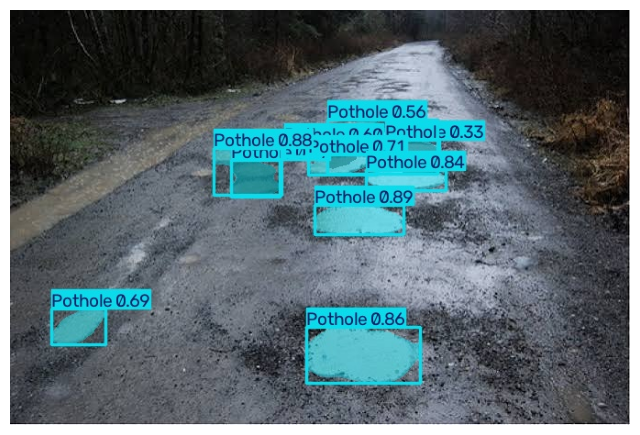

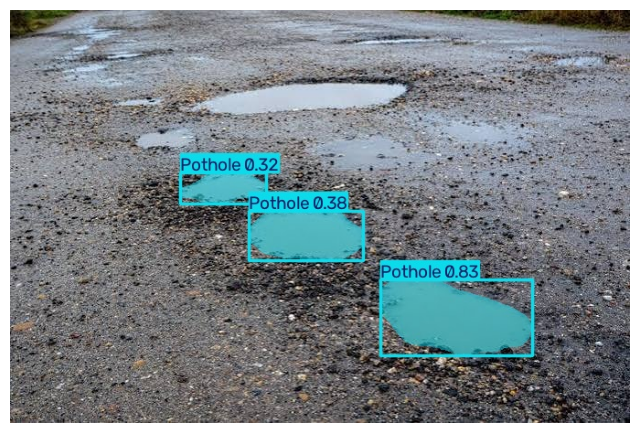

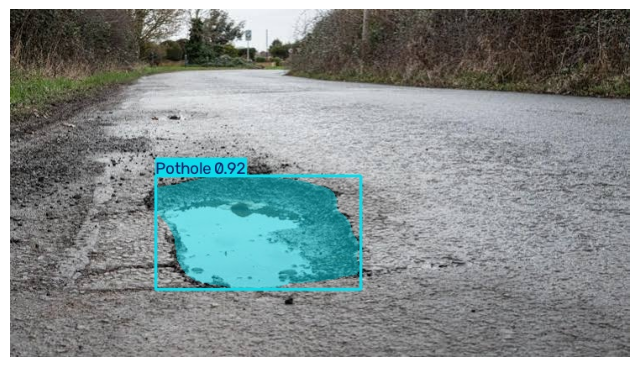

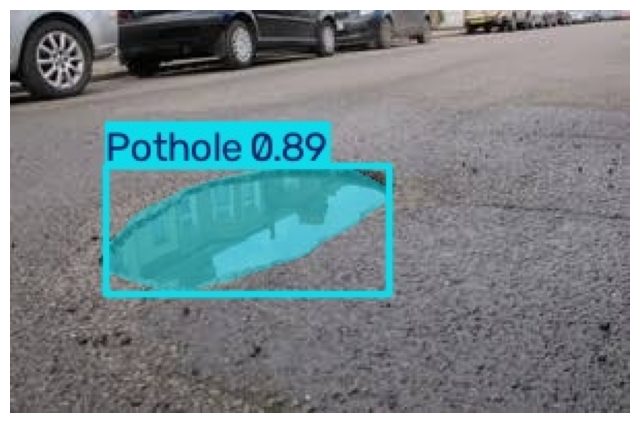

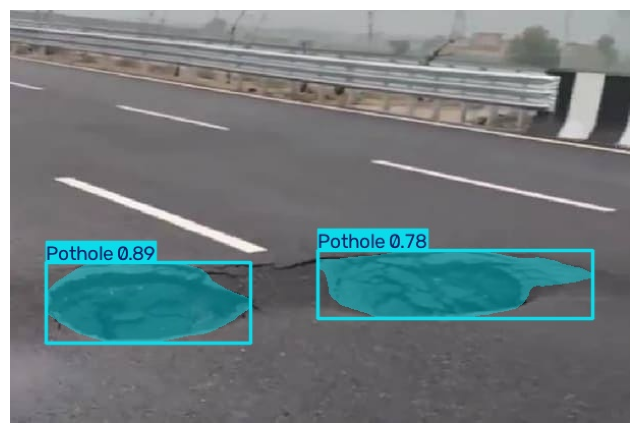

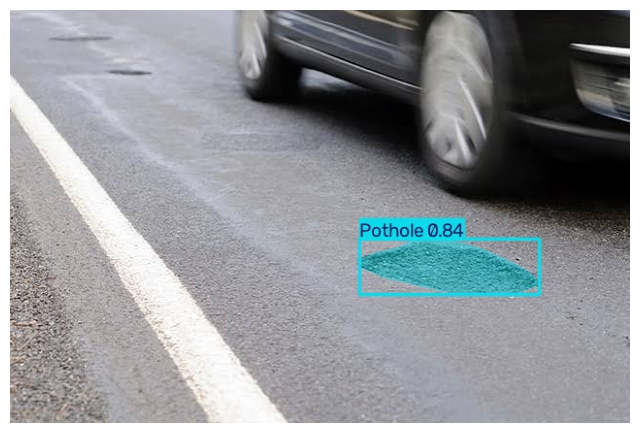

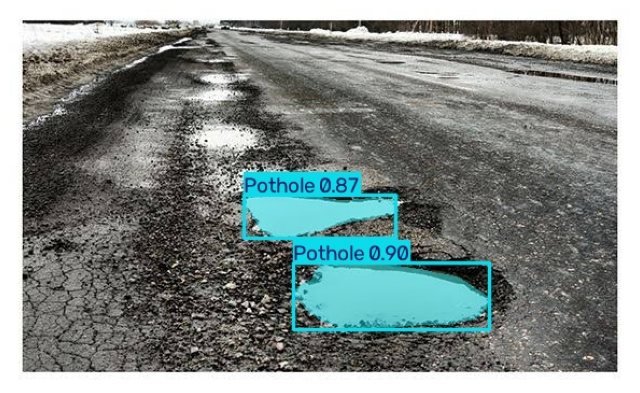

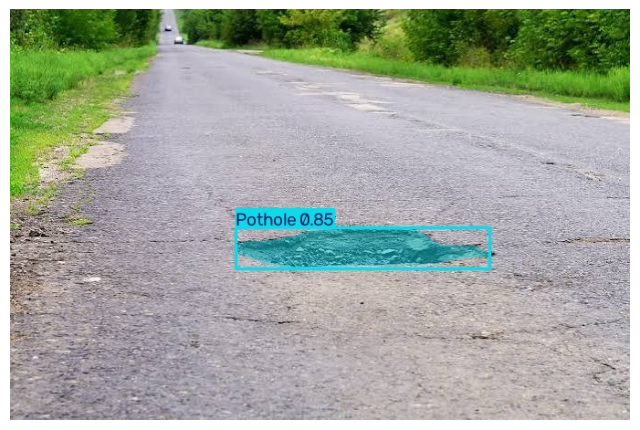

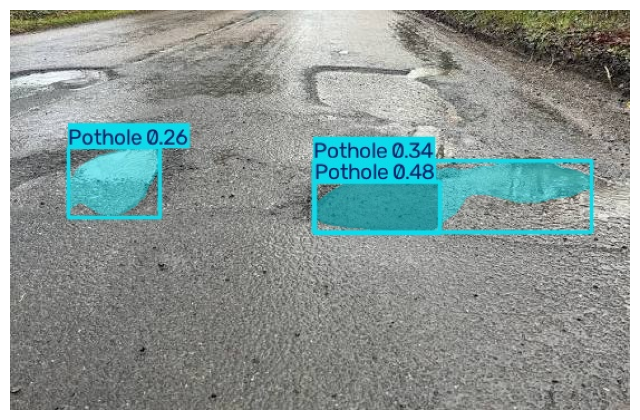

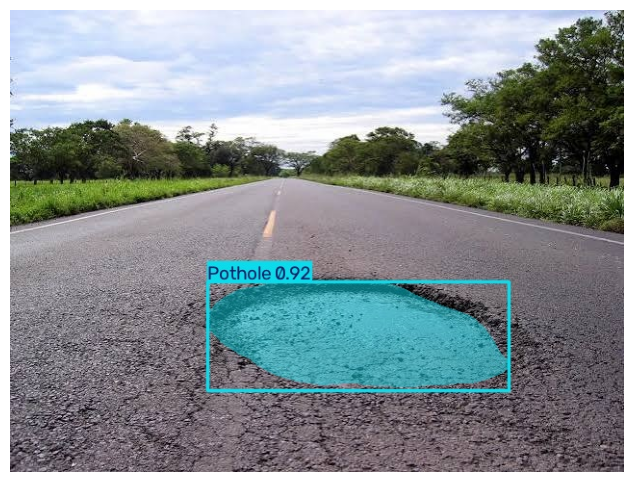

In [17]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder = "/content/runs/segment/predict"

images = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Total images:", len(images))

for image_path in images:
    img = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## 21. Important: resume after a Colab disconnect

If this **new Roboflow training run** is interrupted, use its own `last.pt`.

Example:

```python
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/PTM/pothole_training/roboflow_pothole_v14_100/weights/last.pt"
)

model.train(resume=True)
```

Do not use the old RDD2022 `last.pt` for this new dataset.

If the new run was completed successfully, use `best.pt` for inference.


## 22. Final paths

Expected training output:

`/content/drive/MyDrive/PTM/pothole_training/roboflow_pothole_v14_100/`

Important files:

- `weights/best.pt` — best validation checkpoint
- `weights/last.pt` — latest checkpoint
- training plots/results — inside the run directory

For the semester project, compare this model against the previous RDD2022 model using the same held-out/test images where possible.
